# 03 — Diagnostics\n\nFiguring out why the model fails on Niger. Five artifacts mapping to three hypotheses:\n\n1. Per-band histograms + Wasserstein distance (H1 — covariate shift)\n2. Encoder embeddings + domain classifier + UMAP (H1)\n3. Class frequency comparison: source vs target vs predictions (H2 — prior shift)\n4. Target confusion matrix + entropy analysis (H3 — concept shift)\n5. Zero-training probes: per-chip std, histogram matching, prior correction

In [1]:
import sys, os
sys.path.insert(0, "..")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from pathlib import Path
from scipy.stats import wasserstein_distance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score
import umap

from src.data_acquisition import (
    CLASS_NAMES, NUM_CLASSES, NODATA_LABEL, load_chip, compute_dataset_stats,
)
from src.dataset import LandCoverDataset, load_norm_stats
from src.training import create_model, evaluate, SegmentationMetrics, get_device
from src.diagnostics import (
    collect_raw_pixels, compute_quantiles, extract_embeddings,
    PerChipStandardizedDataset, HistogramMatchedDataset,
    evaluate_with_prior_correction,
)

torch.manual_seed(42)
np.random.seed(42)

SOURCE_DIR = Path("../data/source")
TARGET_DIR = Path("../data/target")
CHECKPOINT_DIR = Path("../checkpoints")
FIG_DIR = Path("../report/figures")

device = get_device("mps")

with open(SOURCE_DIR / "splits.json") as f:
    src_splits = json.load(f)
with open(TARGET_DIR / "splits.json") as f:
    tgt_splits = json.load(f)

mean, std = load_norm_stats(SOURCE_DIR / "norm_stats.json")

src_all = sorted(src_splits["train"] + src_splits["val"])
tgt_all = sorted(tgt_splits["eval"] + tgt_splits["train"])
tgt_eval = tgt_splits["eval"]

BAND_NAMES = ["B2", "B3", "B4", "B8", "NDVI"]
CLASS_COLORS = ["#006400", "#8B4513", "#90EE90", "#FFD700", "#FF0000", "#D2B48C", "#0000FF"]

print(f"Device: {device}")
print(f"Source: {len(src_all)} chips, Target: {len(tgt_all)} chips, Target eval: {len(tgt_eval)} chips")

Device: mps
Source: 300 chips, Target: 300 chips, Target eval: 60 chips


In [2]:
# Load trained model
model = create_model(encoder_name="resnet34", in_channels=5, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(
    CHECKPOINT_DIR / "best_model.pth", map_location=device, weights_only=True
))
model = model.to(device)
model.eval()
print("Model loaded")

Model loaded


## Artifact 1: Input Shift (H1) — Per-band histograms + Wasserstein distance

Loading source pixels:   0%|          | 0/300 [00:00<?, ?it/s]

Loading source pixels:  14%|█▍        | 43/300 [00:00<00:00, 421.79it/s]

Loading source pixels:  30%|██▉       | 89/300 [00:00<00:00, 439.78it/s]

Loading source pixels:  45%|████▌     | 136/300 [00:00<00:00, 450.00it/s]

Loading source pixels:  61%|██████    | 182/300 [00:00<00:00, 451.81it/s]

...

Loading target pixels:  64%|██████▎   | 191/300 [00:00<00:00, 474.90it/s]

Loading target pixels:  80%|███████▉  | 239/300 [00:00<00:00, 467.50it/s]

Loading target pixels:  95%|█████████▌| 286/300 [00:00<00:00, 459.95it/s]

Loading target pixels: 100%|██████████| 300/300 [00:00<00:00, 463.22it/s]

Source pixels: (500000, 5), Target pixels: (500000, 5)


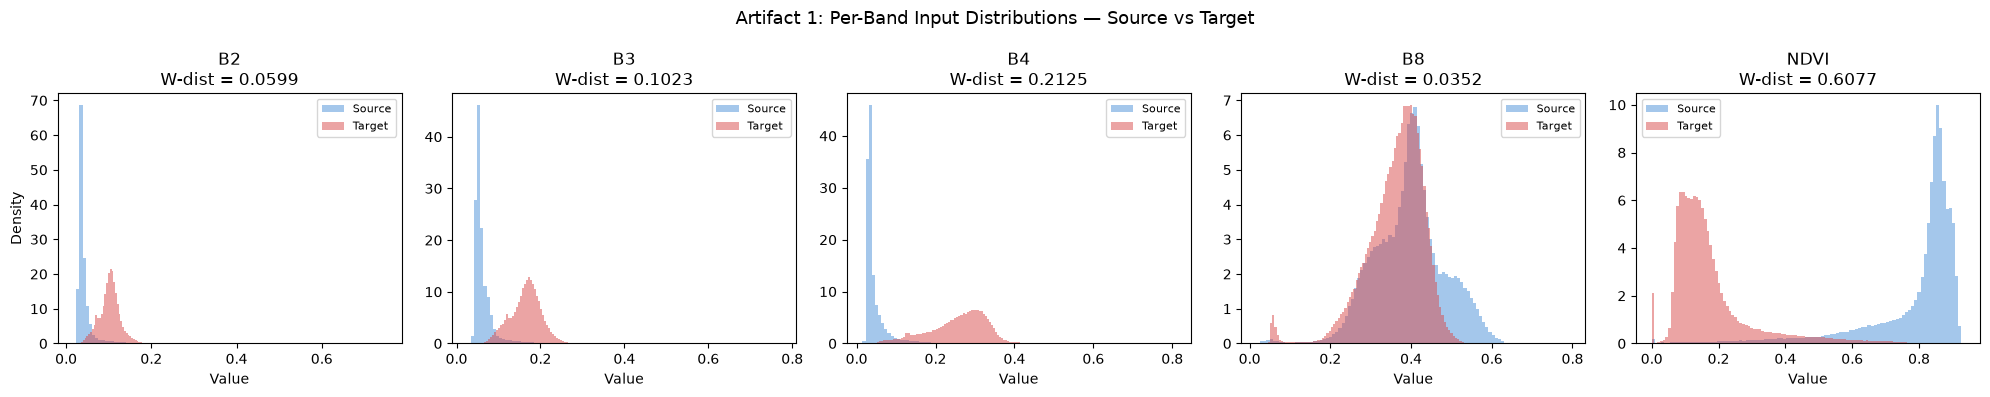

Wasserstein distances: {'B2': '0.0599', 'B3': '0.1023', 'B4': '0.2125', 'B8': '0.0352', 'NDVI': '0.6077'}


In [3]:
src_pixels = collect_raw_pixels(SOURCE_DIR, src_all, max_pixels=500_000)
tgt_pixels = collect_raw_pixels(TARGET_DIR, tgt_all, max_pixels=500_000)
print(f"Source pixels: {src_pixels.shape}, Target pixels: {tgt_pixels.shape}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
w_dists = {}
for i, (ax, band) in enumerate(zip(axes, BAND_NAMES)):
    ax.hist(src_pixels[:, i], bins=100, alpha=0.5, density=True, label="Source", color="#4A90D9")
    ax.hist(tgt_pixels[:, i], bins=100, alpha=0.5, density=True, label="Target", color="#D94A4A")
    wd = wasserstein_distance(src_pixels[:, i], tgt_pixels[:, i])
    w_dists[band] = wd
    ax.set_title(f"{band}\nW-dist = {wd:.4f}")
    ax.set_xlabel("Value")
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Artifact 1: Per-Band Input Distributions — Source vs Target", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_input_shift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wasserstein distances:", {k: f"{v:.4f}" for k, v in w_dists.items()})

## Artifact 2: Feature Shift (H1) — Bottleneck embeddings, domain classifier, UMAP

In [4]:
src_emb = extract_embeddings(model, SOURCE_DIR, src_all, mean, std, device)
tgt_emb = extract_embeddings(model, TARGET_DIR, tgt_all, mean, std, device)
print(f"Source embeddings: {src_emb.shape}, Target embeddings: {tgt_emb.shape}")

# Domain classifier
X = np.concatenate([src_emb, tgt_emb], axis=0)
y = np.array([0] * len(src_emb) + [1] * len(tgt_emb))

cv_scores = cross_val_score(
    LogisticRegressionCV(cv=3, max_iter=1000, random_state=42),
    X, y, cv=5, scoring="accuracy"
)
domain_acc = cv_scores.mean()
domain_acc_std = cv_scores.std()
proxy_a_distance = 2 * (2 * domain_acc - 1)

print(f"Domain classifier accuracy: {domain_acc:.3f} ± {domain_acc_std:.3f}")
print(f"Proxy A-distance: {proxy_a_distance:.3f}")
print("(Near-100% expected for this large a shift; UMAP and probes carry more diagnostic weight)")

Extracting embeddings:   0%|          | 0/38 [00:00<?, ?it/s]

Extracting embeddings:   3%|▎         | 1/38 [00:03<02:07,  3.45s/it]

Extracting embeddings:  11%|█         | 4/38 [00:03<00:23,  1.47it/s]

Extracting embeddings:  21%|██        | 8/38 [00:03<00:08,  3.49it/s]

Extracting embeddings:  32%|███▏      | 12/38 [00:03<00:04,  5.95it/s]

...

Extracting embeddings: 100%|██████████| 38/38 [00:43<00:00,  1.14s/it]


/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2071: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2116: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2129:

Source embeddings: (300, 512), Target embeddings: (300, 512)


Domain classifier accuracy: 0.998 ± 0.003
Proxy A-distance: 1.993
(Near-100% expected for this large a shift; UMAP and probes carry more diagnostic weight)


/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2071: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2116: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2129: 

/Users/qureshsu/Learning/pet_projects/landcover-domain-shift/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


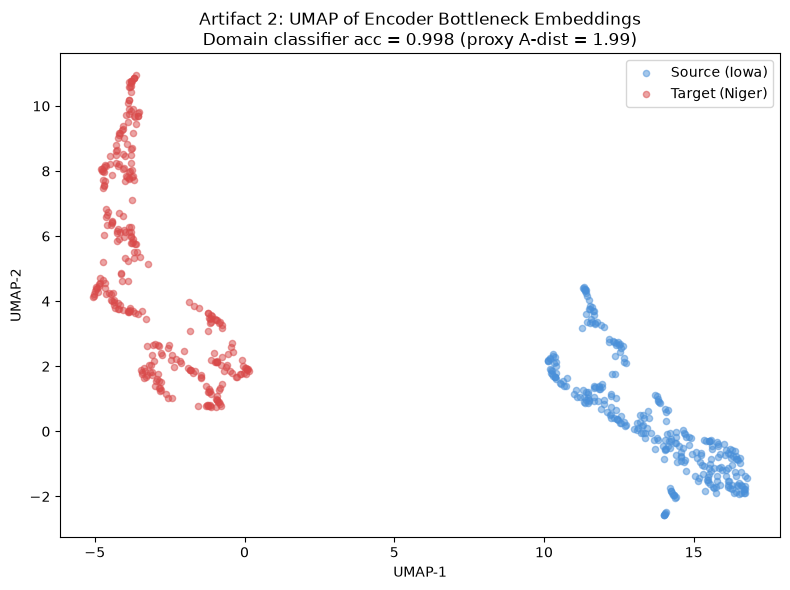

In [5]:
# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_2d = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(emb_2d[:len(src_emb), 0], emb_2d[:len(src_emb), 1],
           c="#4A90D9", alpha=0.5, s=20, label="Source (Iowa)")
ax.scatter(emb_2d[len(src_emb):, 0], emb_2d[len(src_emb):, 1],
           c="#D94A4A", alpha=0.5, s=20, label="Target (Niger)")
ax.set_title(f"Artifact 2: UMAP of Encoder Bottleneck Embeddings\n"
             f"Domain classifier acc = {domain_acc:.3f} (proxy A-dist = {proxy_a_distance:.2f})")
ax.legend()
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_feature_shift.png", dpi=150, bbox_inches="tight")
plt.show()

## Artifact 3: Prior Shift (H2) — Class frequencies: source labels, target labels, target predictions\n\nUsing the same 60 target eval chips for both label and prediction frequencies.

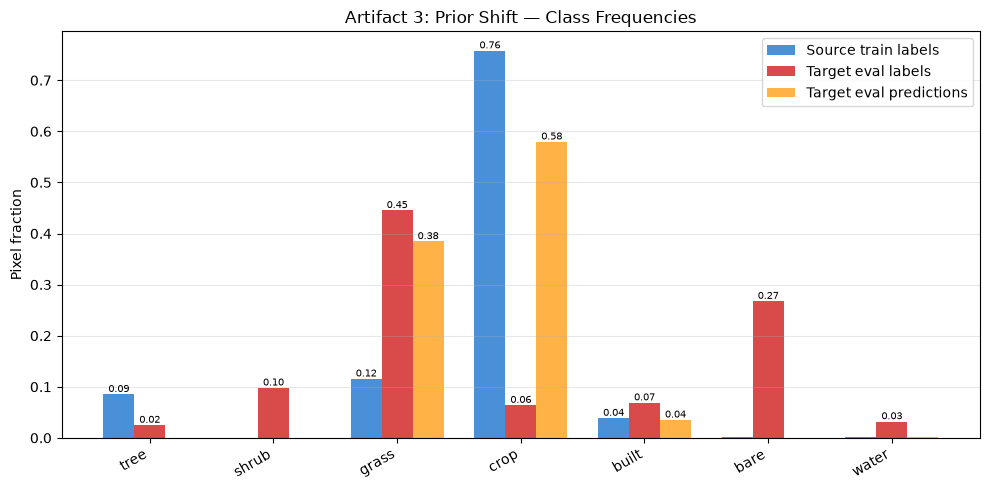

In [6]:
# Source train label frequencies
src_stats = compute_dataset_stats(SOURCE_DIR, src_splits["train"])
src_freq = np.array(src_stats["class_freq"])

# Target eval label frequencies (same 60 chips used for predictions)
tgt_eval_stats = compute_dataset_stats(TARGET_DIR, tgt_eval)
tgt_freq = np.array(tgt_eval_stats["class_freq"])

# Target eval prediction frequencies
tgt_eval_ds = LandCoverDataset(TARGET_DIR, tgt_eval, mean, std, augment=False)
tgt_eval_loader = DataLoader(tgt_eval_ds, batch_size=8, shuffle=False, num_workers=8)

pred_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
total_valid = 0
with torch.no_grad():
    for images, labels in tgt_eval_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu().numpy()
        labels_np = labels.numpy()
        valid = labels_np != NODATA_LABEL
        for c in range(NUM_CLASSES):
            pred_counts[c] += (preds[valid] == c).sum()
        total_valid += valid.sum()
pred_freq = pred_counts / total_valid

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
width = 0.25
ax.bar(x - width, src_freq, width, label="Source train labels", color="#4A90D9")
ax.bar(x, tgt_freq, width, label="Target eval labels", color="#D94A4A")
ax.bar(x + width, pred_freq, width, label="Target eval predictions", color="#FFB347")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("Pixel fraction")
ax.set_title("Artifact 3: Prior Shift — Class Frequencies")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
for offset, freq in [(-width, src_freq), (0, tgt_freq), (width, pred_freq)]:
    for i, f in enumerate(freq):
        if f > 0.005:
            ax.annotate(f"{f:.2f}", (x[i] + offset, f), ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_prior_shift.png", dpi=150, bbox_inches="tight")
plt.show()

## Artifact 4: Concept Shift (H3) — Confusion matrix + predictive entropy\n\nEntropy threshold: source val median entropy (avoids circularity of using target's own median).\nConfident-and-wrong is **consistent with** H3, not proof — neural nets are overconfident on OOD data in general.

In [7]:
# First: compute source val median entropy as reference threshold
src_val_ds = LandCoverDataset(SOURCE_DIR, src_splits["val"], mean, std, augment=False)
src_val_loader = DataLoader(src_val_ds, batch_size=8, shuffle=False, num_workers=8)

src_entropies_all = []
with torch.no_grad():
    for images, labels in src_val_loader:
        images = images.to(device)
        probs = F.softmax(model(images), dim=1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
        labels_np = labels.numpy()
        valid = labels_np != NODATA_LABEL
        src_entropies_all.append(entropy.cpu().numpy()[valid])

src_entropies_all = np.concatenate(src_entropies_all)
src_median_H = np.median(src_entropies_all)
print(f"Source val median entropy: {src_median_H:.4f}")

# Now: target eval entropy + confusion matrix
metrics = SegmentationMetrics()
correct_entropies = []
incorrect_entropies = []

with torch.no_grad():
    for images, labels in tgt_eval_loader:
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)

        preds_np = preds.cpu().numpy()
        labels_np = labels.numpy()
        entropy_np = entropy.cpu().numpy()

        metrics.update_fast(preds_np, labels_np)

        valid = labels_np != NODATA_LABEL
        correct = (preds_np == labels_np) & valid
        incorrect = (preds_np != labels_np) & valid

        if correct.any():
            correct_entropies.append(entropy_np[correct])
        if incorrect.any():
            incorrect_entropies.append(entropy_np[incorrect])

correct_entropies = np.concatenate(correct_entropies)
incorrect_entropies = np.concatenate(incorrect_entropies)

mean_correct_H = correct_entropies.mean()
mean_incorrect_H = incorrect_entropies.mean()
confident_wrong = (incorrect_entropies < src_median_H).mean()

print(f"Mean entropy (correct target pixels):   {mean_correct_H:.4f}")
print(f"Mean entropy (incorrect target pixels): {mean_incorrect_H:.4f}")
print(f"Incorrect pixels with entropy < source median: {confident_wrong:.1%}")

Source val median entropy: 0.2442


Mean entropy (correct target pixels):   0.9438
Mean entropy (incorrect target pixels): 0.7156
Incorrect pixels with entropy < source median: 8.3%


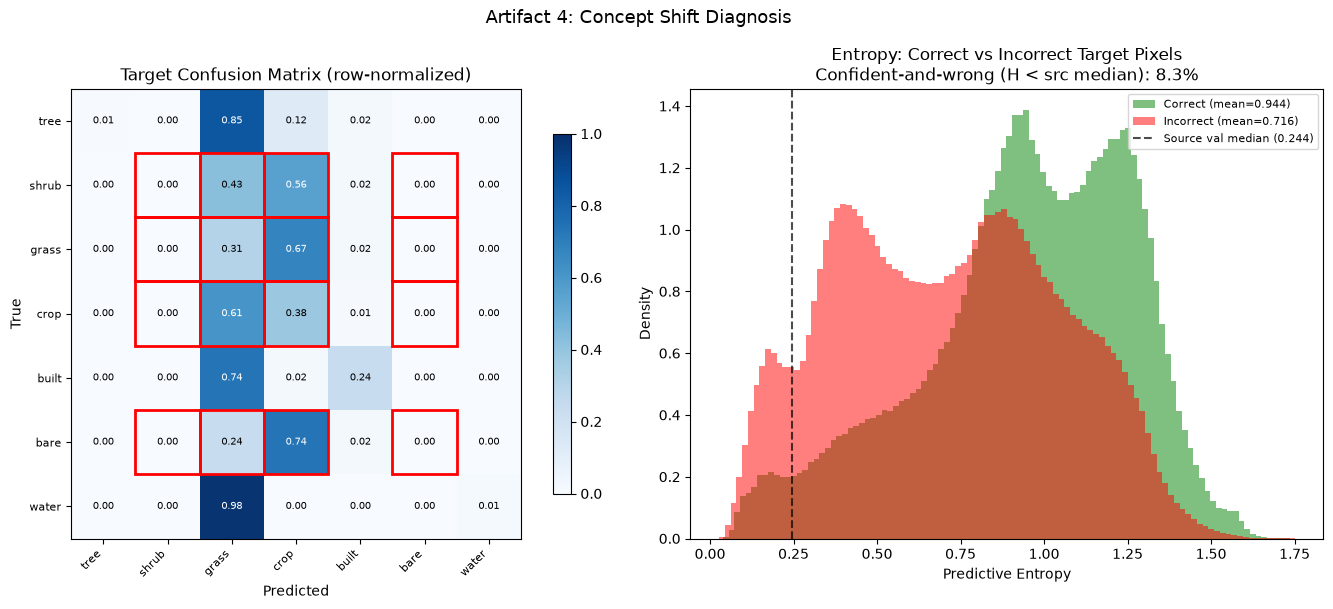

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Row-normalized target confusion matrix
cm = metrics.confusion_matrix
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sums > 0, cm / row_sums, 0.0)

im = ax1.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax1.set_xticks(range(NUM_CLASSES))
ax1.set_yticks(range(NUM_CLASSES))
ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax1.set_yticklabels(CLASS_NAMES, fontsize=8)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Target Confusion Matrix (row-normalized)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        text = f"{val:.2f}" if row_sums[i, 0] > 0 else "-"
        color = "white" if val > 0.5 else "black"
        ax1.text(j, i, text, ha="center", va="center", fontsize=7, color=color)

# Highlight crop/grass/shrub/bare block (indices 1,2,3,5)
for i in [1, 2, 3, 5]:
    for j in [1, 2, 3, 5]:
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             linewidth=2, edgecolor="red", facecolor="none")
        ax1.add_patch(rect)

# Right: Entropy distributions
ax2.hist(correct_entropies, bins=100, alpha=0.5, density=True,
         label=f"Correct (mean={mean_correct_H:.3f})", color="green")
ax2.hist(incorrect_entropies, bins=100, alpha=0.5, density=True,
         label=f"Incorrect (mean={mean_incorrect_H:.3f})", color="red")
ax2.axvline(src_median_H, color="black", linestyle="--", alpha=0.7,
            label=f"Source val median ({src_median_H:.3f})")
ax2.set_xlabel("Predictive Entropy")
ax2.set_ylabel("Density")
ax2.set_title(f"Entropy: Correct vs Incorrect Target Pixels\n"
              f"Confident-and-wrong (H < src median): {confident_wrong:.1%}")
ax2.legend(fontsize=8)

fig.colorbar(im, ax=ax1, shrink=0.8)
fig.suptitle("Artifact 4: Concept Shift Diagnosis", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_concept_shift.png", dpi=150, bbox_inches="tight")
plt.show()

## Artifact 5: Zero-Training Probes\n\nThree probes + source-val controls. Gap recovery = (probe_tgt - base_tgt) / (src_val - base_tgt).\n\n- **Per-chip standardization:** removes absolute radiometric differences (H1 test)\n- **Histogram matching (quantile):** aligns full per-band distributions to source (H1 test)\n- **Prior correction (oracle):** rescales softmax by target/source prior ratio (H2 test, uses true target priors)

In [9]:
# Precompute quantiles for histogram matching (using full pixel sets from Artifact 1)
src_quantiles = compute_quantiles(src_pixels, n_quantiles=1000)
tgt_quantiles = compute_quantiles(tgt_pixels, n_quantiles=1000)

# Baseline numbers from Phase 2
baseline_tgt = 0.063
baseline_src = 0.561
gap = baseline_src - baseline_tgt

criterion = torch.nn.CrossEntropyLoss(ignore_index=NODATA_LABEL)

results = {}

# --- Probe 1: Per-chip standardization ---
# Target
pc_tgt_ds = PerChipStandardizedDataset(TARGET_DIR, tgt_eval)
pc_tgt_loader = DataLoader(pc_tgt_ds, batch_size=8, shuffle=False, num_workers=8)
_, _, pc_tgt_miou, _, _ = evaluate(model, pc_tgt_loader, criterion, device)

# Source val control
pc_src_ds = PerChipStandardizedDataset(SOURCE_DIR, src_splits["val"])
pc_src_loader = DataLoader(pc_src_ds, batch_size=8, shuffle=False, num_workers=8)
_, _, pc_src_miou, _, _ = evaluate(model, pc_src_loader, criterion, device)

results["per_chip_std"] = {"tgt": pc_tgt_miou, "src": pc_src_miou}
print(f"Per-chip std:  tgt={pc_tgt_miou:.4f}, src_val={pc_src_miou:.4f}, recovery={(pc_tgt_miou - baseline_tgt) / gap * 100:.1f}%")

# --- Probe 2: Histogram matching (quantile) ---
hm_tgt_ds = HistogramMatchedDataset(TARGET_DIR, tgt_eval, src_quantiles, tgt_quantiles, mean, std)
hm_tgt_loader = DataLoader(hm_tgt_ds, batch_size=8, shuffle=False, num_workers=8)
_, _, hm_tgt_miou, _, _ = evaluate(model, hm_tgt_loader, criterion, device)

hm_src_ds = HistogramMatchedDataset(SOURCE_DIR, src_splits["val"], src_quantiles,
                                      compute_quantiles(src_pixels, 1000), mean, std)
hm_src_loader = DataLoader(hm_src_ds, batch_size=8, shuffle=False, num_workers=8)
_, _, hm_src_miou, _, _ = evaluate(model, hm_src_loader, criterion, device)

results["hist_match"] = {"tgt": hm_tgt_miou, "src": hm_src_miou}
print(f"Hist match:    tgt={hm_tgt_miou:.4f}, src_val={hm_src_miou:.4f}, recovery={(hm_tgt_miou - baseline_tgt) / gap * 100:.1f}%")

# --- Probe 3: Prior correction (oracle) ---
pc_tgt_iou, pc_tgt_prior_miou, _ = evaluate_with_prior_correction(
    model, tgt_eval_loader, device,
    src_prior=src_freq.tolist(),
    tgt_prior=tgt_freq.tolist(),
)

# Source val control for prior correction (should barely change — source priors match)
pc_src_iou, pc_src_prior_miou, _ = evaluate_with_prior_correction(
    model, src_val_loader, device,
    src_prior=src_freq.tolist(),
    tgt_prior=src_freq.tolist(),  # identity correction for source
)

results["prior_correction"] = {"tgt": pc_tgt_prior_miou, "src": pc_src_prior_miou}
print(f"Prior corr:    tgt={pc_tgt_prior_miou:.4f}, src_val={pc_src_prior_miou:.4f}, recovery={(pc_tgt_prior_miou - baseline_tgt) / gap * 100:.1f}%")

Eval:   0%|          | 0/8 [00:00<?, ?it/s]

Eval:  12%|█▎        | 1/8 [00:02<00:19,  2.81s/it]

Eval:  38%|███▊      | 3/8 [00:02<00:03,  1.29it/s]

Eval:  62%|██████▎   | 5/8 [00:03<00:01,  2.45it/s]

Eval:  88%|████████▊ | 7/8 [00:03<00:00,  3.84it/s]

...

Prior-corrected eval:  50%|█████     | 3/6 [00:02<00:01,  1.77it/s]

Prior-corrected eval:  83%|████████▎ | 5/6 [00:02<00:00,  3.27it/s]

Prior-corrected eval:  83%|████████▎ | 5/6 [00:18<00:00,  3.27it/s]

Prior-corrected eval: 100%|██████████| 6/6 [00:32<00:00,  5.38s/it]

Prior corr:    tgt=0.0140, src_val=0.5610, recovery=-9.8%


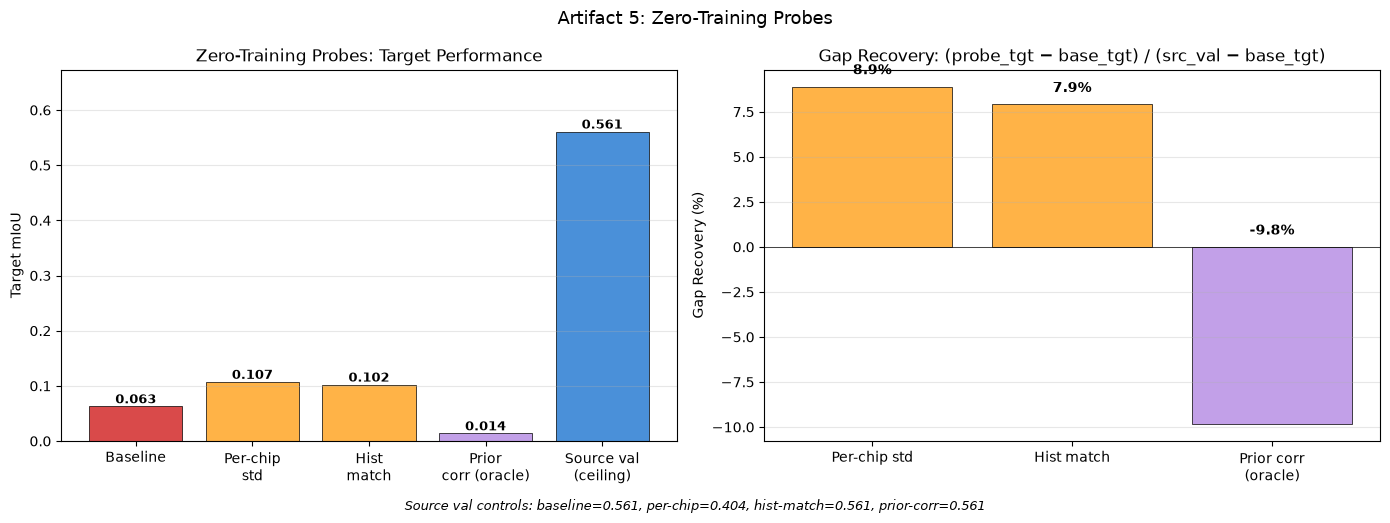


--- Summary ---
Gap: 0.561 - 0.063 = 0.498
  Per-chip std: 8.9% recovery
  Hist match: 7.9% recovery
  Prior correction: -9.8% recovery

Source val controls (should stay near 0.561):
  Per-chip std: 0.404
  Hist match: 0.561
  Prior corr: 0.561


In [10]:
# Probe results figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Target mIoU comparison
methods = ["Baseline", "Per-chip\nstd", "Hist\nmatch", "Prior\ncorr (oracle)", "Source val\n(ceiling)"]
tgt_mious = [baseline_tgt, results["per_chip_std"]["tgt"], results["hist_match"]["tgt"],
             results["prior_correction"]["tgt"], baseline_src]
colors = ["#D94A4A", "#FFB347", "#FFB347", "#C2A0E8", "#4A90D9"]

bars = ax1.bar(methods, tgt_mious, color=colors, edgecolor="black", linewidth=0.5)
for bar, miou in zip(bars, tgt_mious):
    ax1.annotate(f"{miou:.3f}", (bar.get_x() + bar.get_width()/2, miou),
                ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylabel("Target mIoU")
ax1.set_title("Zero-Training Probes: Target Performance")
ax1.set_ylim(0, max(tgt_mious) * 1.2)
ax1.grid(True, alpha=0.3, axis="y")

# Right: Gap recovery %
probe_names = ["Per-chip std", "Hist match", "Prior corr\n(oracle)"]
recoveries = [
    (results["per_chip_std"]["tgt"] - baseline_tgt) / gap * 100,
    (results["hist_match"]["tgt"] - baseline_tgt) / gap * 100,
    (results["prior_correction"]["tgt"] - baseline_tgt) / gap * 100,
]
probe_colors = ["#FFB347", "#FFB347", "#C2A0E8"]
bars2 = ax2.bar(probe_names, recoveries, color=probe_colors, edgecolor="black", linewidth=0.5)
for bar, r in zip(bars2, recoveries):
    ax2.annotate(f"{r:.1f}%", (bar.get_x() + bar.get_width()/2, max(r, 0) + 0.5),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Gap Recovery (%)")
ax2.set_title("Gap Recovery: (probe_tgt − base_tgt) / (src_val − base_tgt)")
ax2.axhline(0, color="black", linewidth=0.5)
ax2.grid(True, alpha=0.3, axis="y")

# Source val controls as text annotation
src_ctrl = (f"Source val controls: baseline={baseline_src:.3f}, "
            f"per-chip={results['per_chip_std']['src']:.3f}, "
            f"hist-match={results['hist_match']['src']:.3f}, "
            f"prior-corr={results['prior_correction']['src']:.3f}")
fig.text(0.5, -0.02, src_ctrl, ha="center", fontsize=9, style="italic")

fig.suptitle("Artifact 5: Zero-Training Probes", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_zero_training_probe.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n--- Summary ---")
print(f"Gap: {baseline_src:.3f} - {baseline_tgt:.3f} = {gap:.3f}")
for name, r in zip(["Per-chip std", "Hist match", "Prior correction"], recoveries):
    print(f"  {name}: {r:.1f}% recovery")
print(f"\nSource val controls (should stay near {baseline_src:.3f}):")
for name, key in [("Per-chip std", "per_chip_std"), ("Hist match", "hist_match"), ("Prior corr", "prior_correction")]:
    print(f"  {name}: {results[key]['src']:.3f}")